# Decision Boundary (Eq. 54)

This notebook computes the hyperbolic decision boundary defined in the paper and visualizes it using MovieLens data.

## Formula (Eq. 54) and data used

Eq. (54) in the paper gives the decision boundary in hyperbolic angle:

$$
t = \left(n + \frac{1}{2}\right) T
$$

Hyperbolic angle (Eq. 21, computed from data):

$$
t = \tanh^{-1}(y/x)
$$

Data mapping in this notebook:
- `rating.csv` → average rating per movie → **x** (1–5 stars, normalized)
- `genome_scores.csv` → tag relevance per movie → **y**

Note: Eq. (54) is written in terms of the hyperbolic angle \(t\). So we must first convert the data \((x,y)\) into \(t\) using Eq. (21), then compare it to the boundary above. If you want **rating‑only** boundaries, we would need a rule to define \(y\) (e.g., set \(y=0\) or map tags from `tag.csv`).

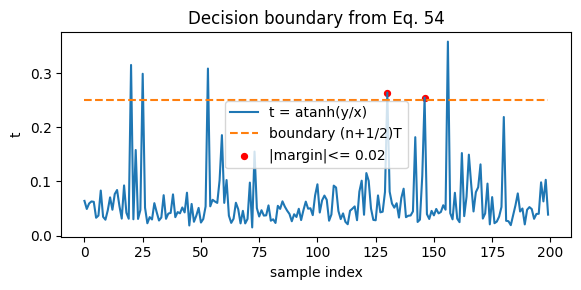

tagId used: 1
mean |margin|: 0.19106315215695538
near-boundary count: 2


In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Resolve project root regardless of where the notebook runs
project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent

data_dir = project_root / "data"

ratings_path = data_dir / "rating.csv"
if not ratings_path.exists():
    ratings_path = data_dir / "ratings.csv"

scores_path = data_dir / "genome_scores.csv"
if not scores_path.exists():
    raise FileNotFoundError("genome_scores.csv not found")

ratings_df = pd.read_csv(ratings_path, usecols=["movieId", "rating"])
movie_rating = ratings_df.groupby("movieId")["rating"].mean().rename("avg_rating")

scores_df = pd.read_csv(scores_path, usecols=["movieId", "tagId", "relevance"])
tag_id = int(scores_df["tagId"].mode().iloc[0])
score_slice = scores_df[scores_df["tagId"] == tag_id].set_index("movieId")

merged = movie_rating.to_frame().join(score_slice[["relevance"]], how="inner")
merged = merged.sample(n=200, random_state=42)

x = (merged["avg_rating"] / 5.0).values + 0.1
raw_y = merged["relevance"].values
scale = np.minimum(0.9 * np.abs(x) / (np.abs(raw_y) + 1e-8), 1.0)
y = raw_y * scale

# Hyperbolic angle t = atanh(y/x)
t = np.arctanh(np.clip(y / x, -0.999, 0.999))

# Decision boundary t = (n + 1/2) T
T = 0.5
n = np.round(t / T - 0.5).astype(int)
boundary = (n + 0.5) * T

plt.figure(figsize=(6, 3))
plt.plot(t, label="t = atanh(y/x)")
plt.plot(boundary, "--", label="boundary (n+1/2)T")

# Mark points near the boundary (classification ambiguity zone)
margin = t - boundary
threshold = 0.02
near_idx = np.where(np.abs(margin) <= threshold)[0]
plt.scatter(near_idx, t[near_idx], color="red", s=18, label=f"|margin|<= {threshold}")

plt.title("Decision boundary from Eq. 54")
plt.xlabel("sample index")
plt.ylabel("t")
plt.legend()
plt.tight_layout()
plt.show()

print("tagId used:", tag_id)
print("mean |margin|:", float(np.mean(np.abs(margin))))
print("near-boundary count:", int(len(near_idx)))


Red points are samples whose hyperbolic angle lies very close to the decision boundary, indicating ambiguous class assignment.